# Mercado de trabajo de IA: México vs Estados Unidos
## 02 — Brecha salarial
### DA: *Mau Vilar*
#### https://github.com/mauvilar

**Qué responde este notebook:** cuánto paga una vacante de IA en México y en Estados Unidos,
cuánto de esa diferencia sobrevive al ajuste por poder adquisitivo (PPP), y si el trabajo remoto
hacia EE. UU. paga una prima dentro de México.

**Regla dura:** ninguna mediana se publica con n < 30 (`resumir_por`, `src/analysis/stats.py`).
Los grupos que no llegan al umbral vuelven con `mediana = NaN` por diseño y se listan en una
tabla; nunca se grafican.

**Aviso temprano:** de las cuatro ciudades mexicanas del alcance del proyecto (CDMX, Querétaro,
Monterrey, Guadalajara), **ninguna** alcanza n ≥ 30 vacantes de IA con salario observado. Ciudad
de México llega a 4; las otras tres, a 0. La sección de México de este notebook no es una tabla
de medianas por ciudad: es la explicación de por qué esa tabla no existe. Cinco metros de Estados
Unidos sí cruzan el umbral y sostienen el análisis cuantitativo.

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, "..")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from src.analysis.stats import resumir_por, mediana_ci
from src.analysis.hypothesis import mann_whitney, welch_log
from src.viz.estilo import (
    PALETA, aplicar_estilo, colores, componer, etiquetar, miles, porcentaje, rejilla,
)

# Gráficas en Editorial v3 (src/viz/estilo.py): fondo rich-black, neutros para el
# contexto y verde sólo para lo que dice el hallazgo.
aplicar_estilo()
FUENTE = "Fuente: API de Adzuna (snapshot del 10 ago 2026) y Kaggle, mannacharya/ai-job-listings · cálculos propios"

from src.features.build import solo_analisis

# El corpus incluye países de calibración, que existen sólo para que el modelo del
# notebook 04 pueda aprender un desnivel entre países. Este notebook publica cifras,
# así que trabaja únicamente sobre México y Estados Unidos.
corpus = pd.read_parquet("../data/processed/vacantes.parquet")
df = solo_analisis(corpus)
if len(corpus) > len(df):
    print(f"{len(corpus) - len(df):,} filas de países de calibración quedan fuera de este notebook")
print(f"{len(df):,} vacantes | {df['salary_observed'].sum():,} con salario observado")
df.head()

6,990 vacantes | 1,666 con salario observado


,posting_id,snapshot_date,source,title_raw,title_norm,company,company_posting_count,company_is_multinational,category,country,...,salary_observed,salary_annual_local,salary_annual_usd,salary_annual_usd_ppp,seniority,tier,skills,description_text,description_lang,url
0,11a69e030bbeb53ec642d827a5ccb1d8f42cd050,2026-08-10,adzuna_mx,RPA Engineer AI Development Experience,rpa engineer ai development experience,AllianceIT Inc,1,False,Unknown,MX,...,True,81000.0,4722.701619,7842.035459,unknown,nucleo,[],"Design, build, test, and deploy Intelligent Ag...",en,https://www.adzuna.com.mx/land/ad/5797062930?s...
1,4c34441a2388bd88259480834442d16d021b0801,2026-08-10,adzuna_mx,Machine Learning Engineer,machine learning engineer,Capital Empresarial Horizonte,6,False,Unknown,MX,...,True,600000.0,34982.974952,58089.151551,unknown,nucleo,"[python, pytorch, tensorflow]",Capital Empresarial Horizonte Empresa Mexicana...,es,https://www.adzuna.com.mx/land/ad/5768169505?s...
2,32f1656a91bd124277eb9ae53e24af7614d2ded7,2026-08-10,adzuna_mx,Ingeniero de Preventa Google Cloud e Inteligen...,ingeniero de preventa google cloud e inteligen...,Capital Empresarial Horizonte,6,False,Unknown,MX,...,True,60000.0,3498.297495,5808.915155,unknown,nucleo,"[gcp, llm]",Capital Empresarial Horizonte Empresa Mexicana...,es,https://www.adzuna.com.mx/land/ad/5800080170?s...
3,33043115125a4d46c1cf05caf42ff7b764f4bbce,2026-08-10,adzuna_mx,Ingeniero en Inteligencia Artificial,ingeniero en inteligencia artificial,Grupo Financiero Inbursa Corporativo,1,False,Unknown,MX,...,True,240000.0,13993.189981,23235.660620,unknown,nucleo,[],Únete al equipo de Innovación de Grupo Finan...,es,https://www.adzuna.com.mx/land/ad/5812515682?s...
4,45f0e4c23e486ef2663196c229a4ac09670eb1ed,2026-08-10,adzuna_mx,Maestra de Matemáticas o Inteligencia Artific...,maestra de matemáticas o inteligencia artific...,VARFRA,1,False,Empleos en educación,MX,...,True,180000.0,10494.892486,17426.745465,unknown,fuera,[],Vacante Descripción del empleo Estamos en bú...,es,https://www.adzuna.com.mx/land/ad/5774880912?s...


In [2]:
ia = df[df["tier"].isin(["nucleo", "anillo"]) & df["salary_observed"]]
mx = ia[ia["country"] == "MX"]
us = ia[ia["country"] == "US"]

print(f"Vacantes de IA (núcleo + anillo) con salario observado: {len(ia)}")
print(f"  México:         {len(mx)}")
print(f"  Estados Unidos: {len(us)}")

Vacantes de IA (núcleo + anillo) con salario observado: 754
  México:         4
  Estados Unidos: 750


## Salarios en México

México se analiza primero porque es donde la regla n ≥ 30 se activa de inmediato: el corte por
ciudad y el corte por seniority fallan los dos, y por la misma razón — faltan observaciones, no
falta interés en medirlas.

### Por ciudad

El plan original pedía medianas para CDMX, Querétaro, Monterrey y Guadalajara. Antes de intentar
calcularlas, el embudo completo: cuántas vacantes hay en cada ciudad, cuántas son de IA
(núcleo + anillo), y cuántas de esas publican salario.

In [3]:
ciudades_objetivo = ["Ciudad de México", "Querétaro", "Monterrey", "Guadalajara"]
mx_todas = df[df["country"] == "MX"]
mx_ia_todas = mx_todas[mx_todas["tier"].isin(["nucleo", "anillo"])]

embudo = pd.DataFrame({
    "vacantes_totales": mx_todas["city"].value_counts(),
    "vacantes_de_ia": mx_ia_todas["city"].value_counts(),
    "ia_con_salario": mx_ia_todas.groupby("city")["salary_observed"].sum(),
}).reindex(ciudades_objetivo).fillna(0).astype(int)
display(embudo)

,vacantes_totales,vacantes_de_ia,ia_con_salario
city,,,
Ciudad de México,249,29,4
Querétaro,16,1,0
Monterrey,24,5,0
Guadalajara,42,10,0


In [4]:
resumen_mx = resumir_por(mx, ["city"], valor="salary_annual_local", min_n=30)
resumen_mx["suficiente"] = resumen_mx["suficiente"].astype(bool)  # object->bool: ~ ya niega bien
display(resumen_mx)

graficables = resumen_mx[resumen_mx["suficiente"]]
insuficientes = resumen_mx[~resumen_mx["suficiente"]]

if len(graficables):
    # Con el corpus actual no se dibuja: ninguna ciudad llega a 30. Queda lista para cuando lleguen.
    graficables = graficables.sort_values("mediana")
    tope = graficables.iloc[-1]
    fig, ax = plt.subplots(figsize=(11, 4.8))
    y = np.arange(len(graficables))
    ax.hlines(y, graficables["ic_inf"], graficables["ic_sup"], color=PALETA["neutro"], linewidth=2.5, zorder=1)
    ax.scatter(graficables["mediana"], y, s=110, zorder=3,
               color=colores(graficables["city"], tope["city"], resto=PALETA["neutro_claro"]))
    ax.set_yticks(y, graficables["city"])
    for yi, (_, r) in zip(y, graficables.iterrows()):
        ax.text(r["ic_sup"], yi, f"   {r['mediana']:,.0f} · n={int(r['n'])}", va="center", fontsize=9.5,
                color=PALETA["tinta"] if r["city"] == tope["city"] else PALETA["tenue"])
    ax.set_xlabel("Salario anual mediano (MXN). La línea es el intervalo de confianza del 90%")
    miles(ax, "x")
    rejilla(ax, "x")
    componer(
        fig,
        f"{tope['city']} tiene la mediana más alta de México: {tope['mediana']:,.0f} pesos al año",
        "Mediana anual por ciudad con intervalo bootstrap del 90%. Vacantes de IA con salario publicado; sólo ciudades con 30 o más.",
        FUENTE,
    )
else:
    print("Ninguna ciudad mexicana alcanza n >= 30. No se dibuja ninguna gráfica de medianas:")
    print("graficar aquí presentaría como estimación algo que no lo es.")

if len(insuficientes):
    print("\nMuestra insuficiente, NO se grafican:")
    print(insuficientes[["city", "n"]].to_string(index=False))
    print("\nQuerétaro, Monterrey y Guadalajara ni siquiera aparecen en esta tabla: tienen 0 filas")
    print("en el corte de IA-con-salario (ver el embudo arriba), así que resumir_por no genera grupo para ellas.")

,city,n,suficiente,mediana,ic_inf,ic_sup,q1,q3
0,Ciudad de México,4,False,NaN,NaN,NaN,NaN,NaN


Ninguna ciudad mexicana alcanza n >= 30. No se dibuja ninguna gráfica de medianas:
graficar aquí presentaría como estimación algo que no lo es.

Muestra insuficiente, NO se grafican:
            city  n
Ciudad de México  4

Querétaro, Monterrey y Guadalajara ni siquiera aparecen en esta tabla: tienen 0 filas
en el corte de IA-con-salario (ver el embudo arriba), así que resumir_por no genera grupo para ellas.


In [5]:
valores_mx = sorted(mx["salary_annual_local"].tolist())
print("Los 4 salarios mexicanos observados (MXN/año):", [f"{v:,.0f}" for v in valores_mx])
print(f"Razón máximo/mínimo: {max(valores_mx) / min(valores_mx):.1f}x")

med, lo, hi = mediana_ci(mx["salary_annual_usd_ppp"])
print(f"\nSi se ignora la regla n>=30 y se hace bootstrap igual sobre estos 4 valores (PPP):")
print(f"  mediana=${med:,.0f}  IC90%=[${lo:,.0f}, ${hi:,.0f}]  ancho=${hi - lo:,.0f}")

sf_bay = us.loc[us["metro"] == "SF Bay Area", "salary_annual_usd_ppp"]
med_sf, lo_sf, hi_sf = mediana_ci(sf_bay)
print(f"Contraste, SF Bay Area (n={sf_bay.count()}): mediana=${med_sf:,.0f}  IC90%=[${lo_sf:,.0f}, ${hi_sf:,.0f}]  ancho=${hi_sf - lo_sf:,.0f}")
print(f"\nEl IC de México es {(hi - lo) / (hi_sf - lo_sf):.1f}x más ancho que el de SF Bay Area,")
print("y su ancho supera 3x a la propia mediana que pretende acotar. Ésa es la regla n>=30 hecha número.")

Los 4 salarios mexicanos observados (MXN/año): ['60,000', '81,000', '240,000', '600,000']
Razón máximo/mínimo: 10.0x

Si se ignora la regla n>=30 y se hace bootstrap igual sobre estos 4 valores (PPP):
  mediana=$15,539  IC90%=[$5,809, $58,089]  ancho=$52,280
Contraste, SF Bay Area (n=319): mediana=$225,000  IC90%=[$216,300, $226,800]  ancho=$10,500

El IC de México es 5.0x más ancho que el de SF Bay Area,
y su ancho supera 3x a la propia mediana que pretende acotar. Ésa es la regla n>=30 hecha número.


**Conclusión — Por ciudad.** Ninguna de las cuatro ciudades mexicanas del alcance del proyecto
alcanza n ≥ 30 vacantes de IA con salario observado. Ciudad de México reúne 249 vacantes en
total, de las cuales 29 son de IA, y de ésas sólo 4 publican salario. Querétaro, Monterrey y
Guadalajara tienen vacantes de IA (1, 5 y 10 respectivamente) pero **cero** con salario
publicado. No es un problema de muestreo que se resuelva recolectando una semana más: es la
opacidad salarial mexicana descrita en la tesis del proyecto, medida directamente. Los 4 salarios
de CDMX (60,000 · 81,000 · 240,000 · 600,000 MXN/año) tienen un rango de 10x entre sí; el
bootstrap ingenuo sobre esos 4 valores produce un IC90% de \$5,809–\$58,089 (dólares PPP), más
ancho que la propia mediana que delimita. Se reportan como anécdota en la sección de brecha, no
como estimación.

### Por seniority

El mismo corte, ahora por seniority declarado en la descripción de la vacante.

In [6]:
resumen_mx_seniority = resumir_por(mx, ["seniority"], valor="salary_annual_local", min_n=30)
display(resumen_mx_seniority)
print("Seniority presente en las vacantes mexicanas con salario:", mx["seniority"].unique().tolist())

,seniority,n,suficiente,mediana,ic_inf,ic_sup,q1,q3
0,unknown,4,False,NaN,NaN,NaN,NaN,NaN


Seniority presente en las vacantes mexicanas con salario: ['unknown']


**Conclusión — Por seniority.** Las 4 vacantes mexicanas con salario observado declaran
seniority = `unknown` **las cuatro**. No es sólo que la muestra sea insuficiente (n=4 < 30): no
hay ninguna variación de seniority que segmentar. El campo `seniority` se extrae del texto de la
descripción, y en este corte no aporta nada porque la descripción no lo menciona. El desglose por
seniority que sí funciona es el de Estados Unidos, en la sección siguiente.

## Salarios en Estados Unidos

Con 750 vacantes de IA con salario observado, Estados Unidos es donde la regla n ≥ 30 deja de
ser un obstáculo y empieza a producir números.

### Por metro

Medianas con intervalo de confianza bootstrap (90 %) para los metros de EE. UU. definidos en el
alcance del proyecto, en dólares nominales.

,metro,n,suficiente,mediana,ic_inf,ic_sup,q1,q3
0,SF Bay Area,319,True,225000.0,216300.00,226800.0,192500.0,275000.000
1,NYC,116,True,200000.0,185000.00,210000.0,144375.0,230000.000
2,Boston,64,True,182500.0,175000.00,195000.0,153750.0,220872.125
3,Seattle,63,True,202500.0,185000.00,207500.0,170150.0,220650.000
4,Austin,38,True,197575.0,168044.25,209750.0,155500.0,230625.000
5,Los Angeles,20,False,NaN,NaN,NaN,NaN,NaN


Muestra insuficiente, NO se grafican:


      metro  n
Los Angeles 20

130 vacantes de EE. UU. no mapean a un metro de config/cities.yml y quedan fuera de este corte.


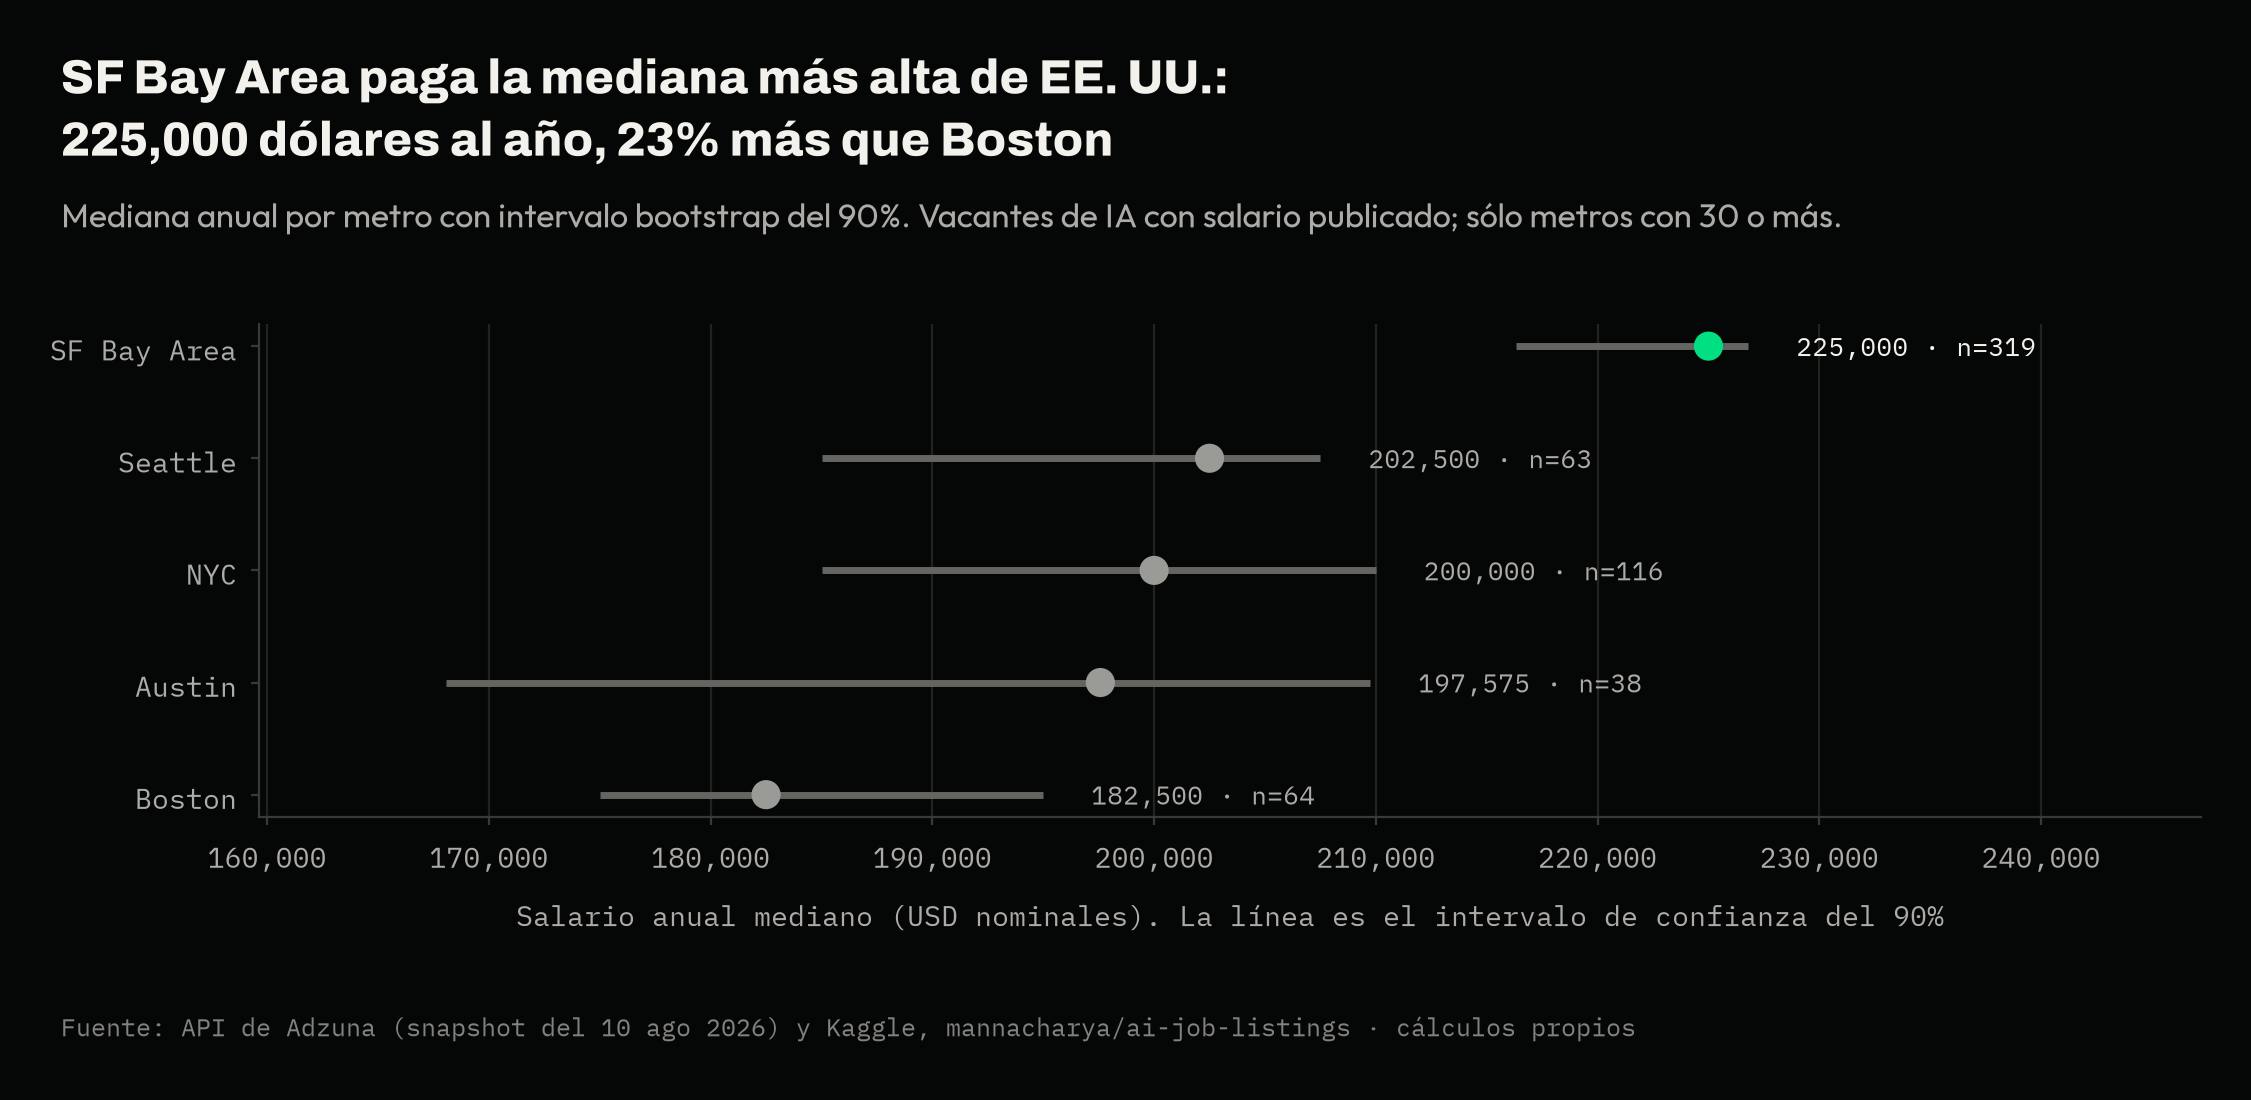

In [7]:
us_metro = us[us["metro"].notna()]
sin_metro = len(us) - len(us_metro)

resumen_us_metro = resumir_por(us_metro, ["metro"], valor="salary_annual_usd", min_n=30)
resumen_us_metro["suficiente"] = resumen_us_metro["suficiente"].astype(bool)
display(resumen_us_metro)

graficables = resumen_us_metro[resumen_us_metro["suficiente"]].sort_values("mediana")
insuficientes = resumen_us_metro[~resumen_us_metro["suficiente"]]

tope, piso = graficables.iloc[-1], graficables.iloc[0]
fig, ax = plt.subplots(figsize=(11, 5.4))
y = np.arange(len(graficables))
ax.hlines(y, graficables["ic_inf"], graficables["ic_sup"], color=PALETA["neutro"], linewidth=2.5, zorder=1)
ax.scatter(graficables["mediana"], y, s=110, zorder=3,
           color=colores(graficables["metro"], tope["metro"], resto=PALETA["neutro_claro"]))
ax.set_yticks(y, graficables["metro"])
for yi, (_, r) in zip(y, graficables.iterrows()):
    ax.text(r["ic_sup"], yi, f"   {r['mediana']:,.0f} · n={int(r['n'])}", va="center", fontsize=9.5,
            color=PALETA["tinta"] if r["metro"] == tope["metro"] else PALETA["tenue"])
ax.set_xlim(graficables["ic_inf"].min() * 0.95, graficables["ic_sup"].max() * 1.09)
ax.set_xlabel("Salario anual mediano (USD nominales). La línea es el intervalo de confianza del 90%")
miles(ax, "x")
rejilla(ax, "x")
componer(
    fig,
    f"{tope['metro']} paga la mediana más alta de EE. UU.: {tope['mediana']:,.0f} dólares al año, {tope['mediana'] / piso['mediana'] - 1:.0%} más que {piso['metro']}",
    "Mediana anual por metro con intervalo bootstrap del 90%. Vacantes de IA con salario publicado; sólo metros con 30 o más.",
    FUENTE,
)

if len(insuficientes):
    print("Muestra insuficiente, NO se grafican:")
    print(insuficientes[["metro", "n"]].to_string(index=False))
print(f"\n{sin_metro:,} vacantes de EE. UU. no mapean a un metro de config/cities.yml y quedan fuera de este corte.")

**Conclusión — Por metro.** Cinco metros de EE. UU. alcanzan n ≥ 30: SF Bay Area (n=319,
mediana \$225,000), Seattle (n=63, \$202,500), NYC (n=116, \$200,000), Austin (n=38, \$197,575) y
Boston (n=64, \$182,500). Los Ángeles se queda en n=20 y no se grafica. SF Bay Area paga ~23% más
que Boston, el metro suficiente más barato — una brecha real, pero mucho menor que la que separa
a cualquiera de estos metros de México.

### Por seniority

Mismo corte para EE. UU., ahora por seniority.

,seniority,n,suficiente,mediana,ic_inf,ic_sup,q1,q3
0,unknown,248,True,200000.00,190250.0,201900.0,150000.000,230000.0
1,sr,206,True,196520.25,185000.0,201075.0,155930.625,225000.0
2,lead,85,True,190000.00,175000.0,200000.0,150000.000,237500.0
3,staff,81,True,238750.00,229000.0,250000.0,200000.000,280500.0
4,mid,51,True,190000.00,145000.0,200000.0,132500.000,223750.0
5,principal,38,True,232625.00,220800.0,239525.0,198442.500,262600.0
6,jr,29,False,NaN,NaN,NaN,NaN,NaN
7,intern,12,False,NaN,NaN,NaN,NaN,NaN


Muestra insuficiente, NO se grafican:
seniority  n
       jr 29
   intern 12


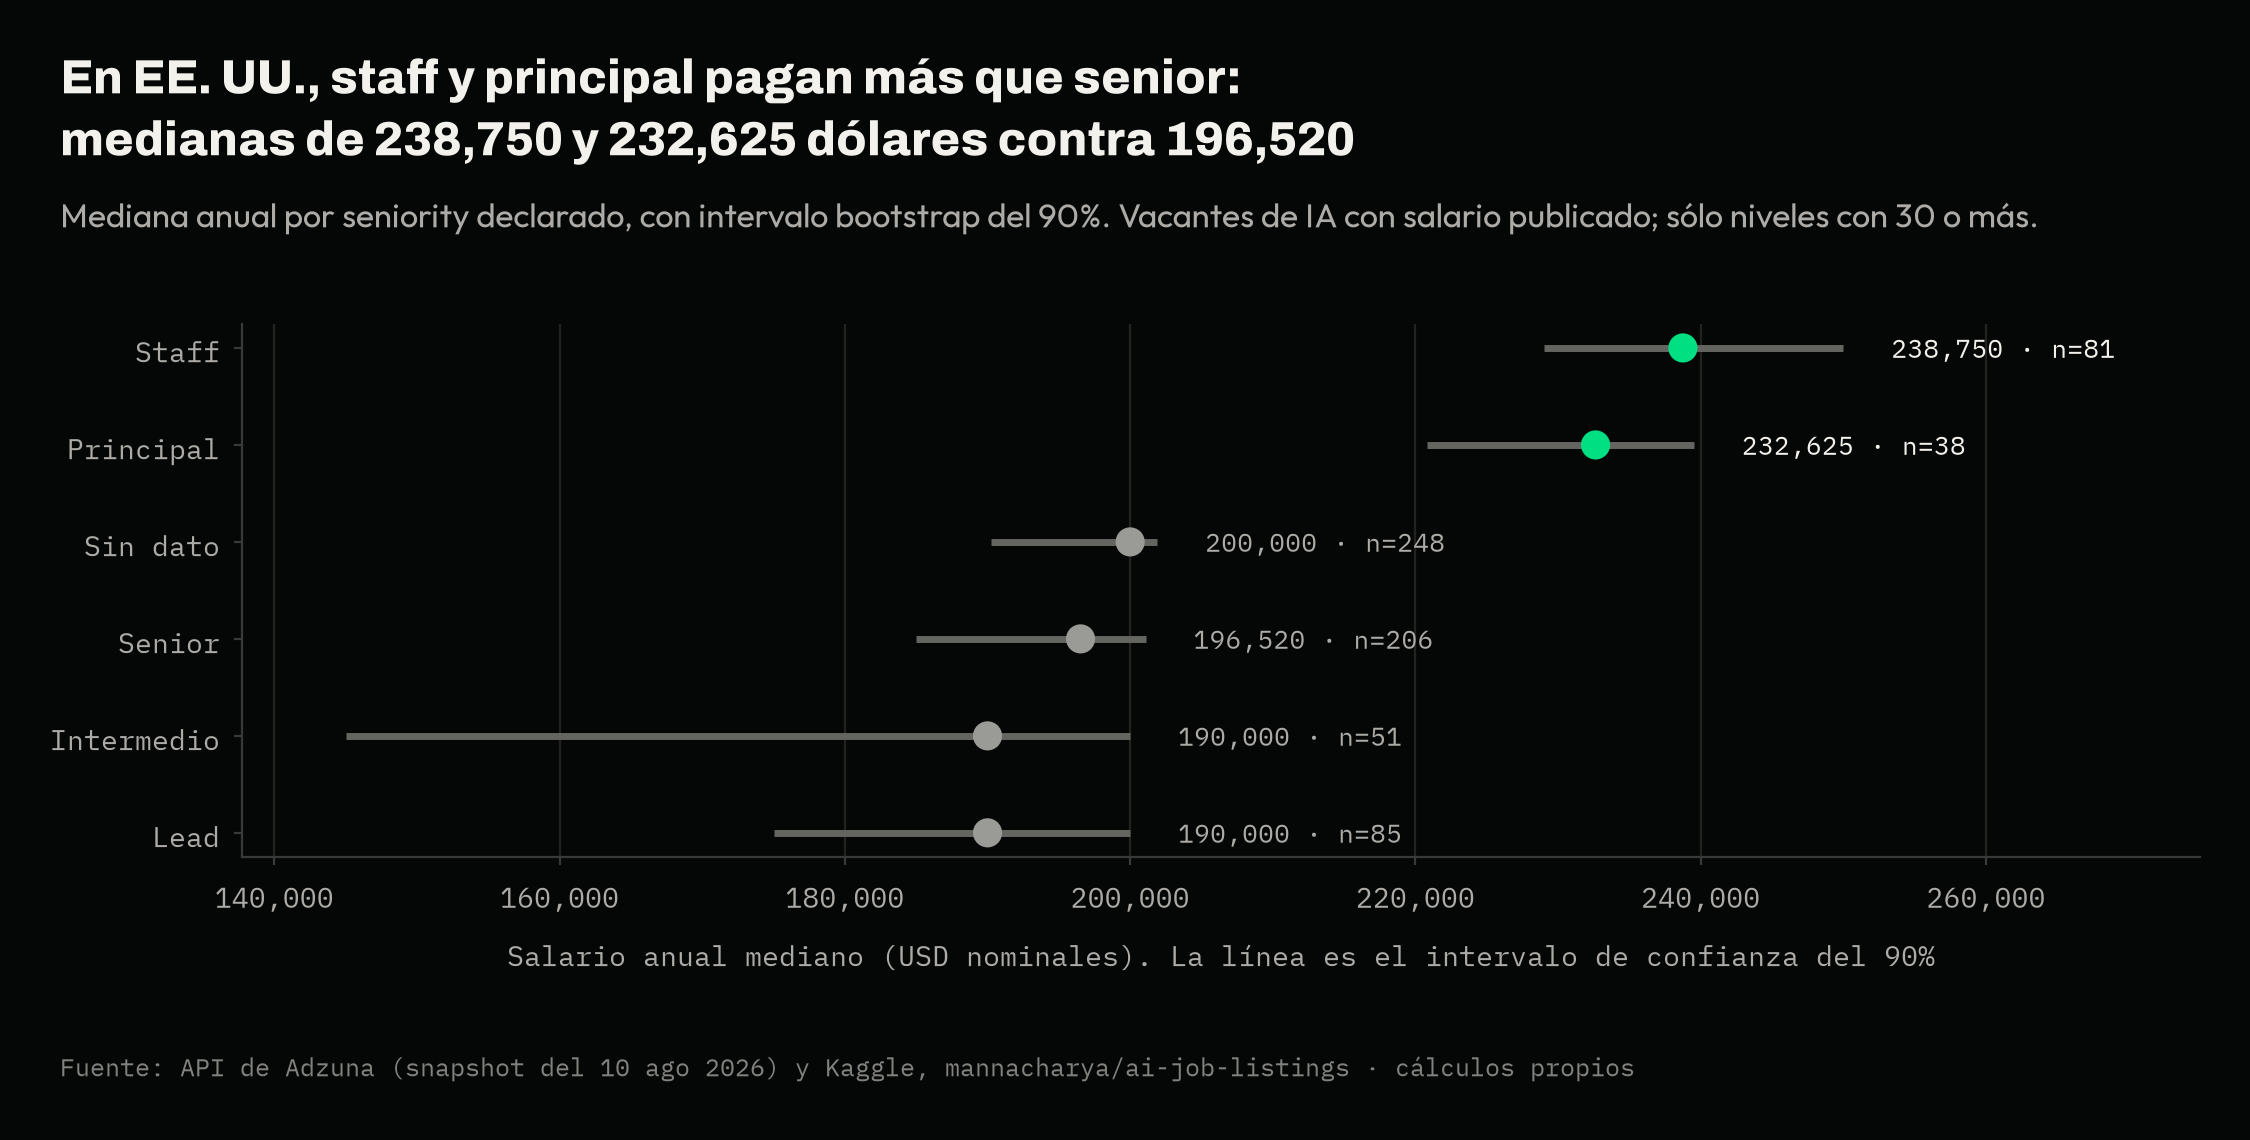

In [8]:
resumen_us_seniority = resumir_por(us, ["seniority"], valor="salary_annual_usd", min_n=30)
resumen_us_seniority["suficiente"] = resumen_us_seniority["suficiente"].astype(bool)
display(resumen_us_seniority)

graficables = resumen_us_seniority[resumen_us_seniority["suficiente"]].sort_values("mediana")
insuficientes = resumen_us_seniority[~resumen_us_seniority["suficiente"]]

NIVEL = {"intern": "Becario", "jr": "Junior", "mid": "Intermedio", "sr": "Senior", "lead": "Lead",
         "staff": "Staff", "principal": "Principal", "unknown": "Sin dato"}
mediana = graficables.set_index("seniority")["mediana"]
fig, ax = plt.subplots(figsize=(11, 5.6))
y = np.arange(len(graficables))
ax.hlines(y, graficables["ic_inf"], graficables["ic_sup"], color=PALETA["neutro"], linewidth=2.5, zorder=1)
ax.scatter(graficables["mediana"], y, s=110, zorder=3,
           color=colores(graficables["seniority"], {"staff", "principal"}, resto=PALETA["neutro_claro"]))
ax.set_yticks(y, graficables["seniority"].map(NIVEL))
for yi, (_, r) in zip(y, graficables.iterrows()):
    ax.text(r["ic_sup"], yi, f"   {r['mediana']:,.0f} · n={int(r['n'])}", va="center", fontsize=9.5,
            color=PALETA["tinta"] if r["seniority"] in ("staff", "principal") else PALETA["tenue"])
ax.set_xlim(graficables["ic_inf"].min() * 0.95, graficables["ic_sup"].max() * 1.1)
ax.set_xlabel("Salario anual mediano (USD nominales). La línea es el intervalo de confianza del 90%")
miles(ax, "x")
rejilla(ax, "x")
componer(
    fig,
    f"En EE. UU., staff y principal pagan más que senior: medianas de {mediana['staff']:,.0f} y {mediana['principal']:,.0f} dólares contra {mediana['sr']:,.0f}",
    "Mediana anual por seniority declarado, con intervalo bootstrap del 90%. Vacantes de IA con salario publicado; sólo niveles con 30 o más.",
    FUENTE,
)

if len(insuficientes):
    print("Muestra insuficiente, NO se grafican:")
    print(insuficientes[["seniority", "n"]].to_string(index=False))

**Conclusión — Por seniority (EE. UU.).** `staff` (n=81, \$238,750) y `principal` (n=38,
\$232,625) son los niveles mejor pagados observados, por encima incluso de `sr` (n=206,
\$196,520) — consistente con que "staff/principal" en tecnología suele ser una vía de progresión
técnica paralela a management, no un nivel intermedio. `intern` (n=12) no alcanza el umbral y no
se grafica. `unknown` (n=248, el grupo más grande) paga cerca de la mediana general, lo que
sugiere que las vacantes sin seniority declarado no están sesgadas hacia ningún extremo.

## La brecha

Con Estados Unidos medible y México reducido a 4 observaciones en una sola ciudad, esta sección
no compara dos medianas confiables: compara una mediana real contra una anécdota, y es explícita
sobre cuál es cuál.

### Brecha nominal

Comparación en dólares corrientes, sin ajustar por poder adquisitivo.

In [9]:
nominal = resumir_por(ia, ["country"], valor="salary_annual_usd", min_n=30)
display(nominal)

mediana_us_nom = nominal.set_index("country").loc["US", "mediana"]
mediana_mx_nom = mx["salary_annual_usd"].median()  # n=4, anécdota: no cumple n>=30

print(f"Estados Unidos (n={len(us)}): mediana ${mediana_us_nom:,.0f} USD nominales")
print(f"México (n={len(mx)}, ANÉCDOTA — no cumple n>=30): 'mediana' ${mediana_mx_nom:,.0f} USD nominales")
print(f"Razón nominal US/MX, anecdótica: {mediana_us_nom / mediana_mx_nom:.1f}x")

,country,n,suficiente,mediana,ic_inf,ic_sup,q1,q3
0,US,750,True,200000.0,195000.0,200250.0,152500.0,237500.0
1,MX,4,False,NaN,NaN,NaN,NaN,NaN


Estados Unidos (n=750): mediana $200,000 USD nominales
México (n=4, ANÉCDOTA — no cumple n>=30): 'mediana' $9,358 USD nominales
Razón nominal US/MX, anecdótica: 21.4x


**Conclusión — Brecha nominal.** `resumir_por` a nivel país confirma lo mismo que a nivel
ciudad: México con n=4 vuelve `mediana = NaN` por diseño. El número que sigue no es una
estimación del mercado mexicano: es la mediana literal de 4 observaciones, ≈\$9,358 USD
nominales contra \$200,000 en EE. UU., una razón de ~21x. Se reporta porque omitirlo sería
esconder el dato, no porque sostenga una afirmación sobre "cuánto paga México".

### Brecha ajustada por poder adquisitivo

El tipo de cambio nominal sobrevalora lo que un dólar "vale" fuera de EE. UU.: no refleja que un
peso rinde más dentro de México que su conversión directa a dólares. El factor PPP del Banco
Mundial (`PA.NUS.PPP`, MX=10.33, US=1.0) corrige eso. Para México, `salary_annual_usd_ppp` es por
eso **mayor** que `salary_annual_usd` — no es un error, es el ajuste haciendo su trabajo.

In [10]:
ppp = resumir_por(ia, ["country"], valor="salary_annual_usd_ppp", min_n=30)
display(ppp)

mediana_us_ppp = ppp.set_index("country").loc["US", "mediana"]
mediana_mx_ppp = mx["salary_annual_usd_ppp"].median()  # n=4, anécdota

print(f"Estados Unidos (n={len(us)}): mediana ${mediana_us_ppp:,.0f} USD PPP (factor=1.0, igual al nominal)")
print(f"México (n={len(mx)}, ANÉCDOTA): 'mediana' ${mediana_mx_ppp:,.0f} USD PPP, vs ${mediana_mx_nom:,.0f} nominales")
print(f"El ajuste PPP multiplica el número mexicano por {mediana_mx_ppp / mediana_mx_nom:.2f}x")

razon_nominal = mediana_us_nom / mediana_mx_nom
razon_ppp = mediana_us_ppp / mediana_mx_ppp
print(f"\nRazón US/MX nominal, anecdótica: {razon_nominal:.1f}x")
print(f"Razón US/MX en PPP, anecdótica:  {razon_ppp:.1f}x")
print("El tipo de cambio exagera la brecha frente al poder adquisitivo real, pero ambas razones")
print("descansan sobre las mismas 4 observaciones mexicanas: ninguna de las dos es una estimación.")

,country,n,suficiente,mediana,ic_inf,ic_sup,q1,q3
0,US,750,True,200000.0,195000.0,200250.0,152500.0,237500.0
1,MX,4,False,NaN,NaN,NaN,NaN,NaN


Estados Unidos (n=750): mediana $200,000 USD PPP (factor=1.0, igual al nominal)
México (n=4, ANÉCDOTA): 'mediana' $15,539 USD PPP, vs $9,358 nominales
El ajuste PPP multiplica el número mexicano por 1.66x

Razón US/MX nominal, anecdótica: 21.4x
Razón US/MX en PPP, anecdótica:  12.9x
El tipo de cambio exagera la brecha frente al poder adquisitivo real, pero ambas razones
descansan sobre las mismas 4 observaciones mexicanas: ninguna de las dos es una estimación.


,country,metro,n,suficiente,mediana,ic_inf,ic_sup,q1,q3
0,US,SF Bay Area,319,True,225000.0,216300.00,226800.0,192500.0,275000.000
1,US,NYC,116,True,200000.0,185000.00,210000.0,144375.0,230000.000
2,US,Boston,64,True,182500.0,175000.00,195000.0,153750.0,220872.125
3,US,Seattle,63,True,202500.0,185000.00,207500.0,170150.0,220650.000
4,US,Austin,38,True,197575.0,168044.25,209750.0,155500.0,230625.000
5,US,Los Angeles,20,False,NaN,NaN,NaN,NaN,NaN
6,MX,Valle de México,4,False,NaN,NaN,NaN,NaN,NaN


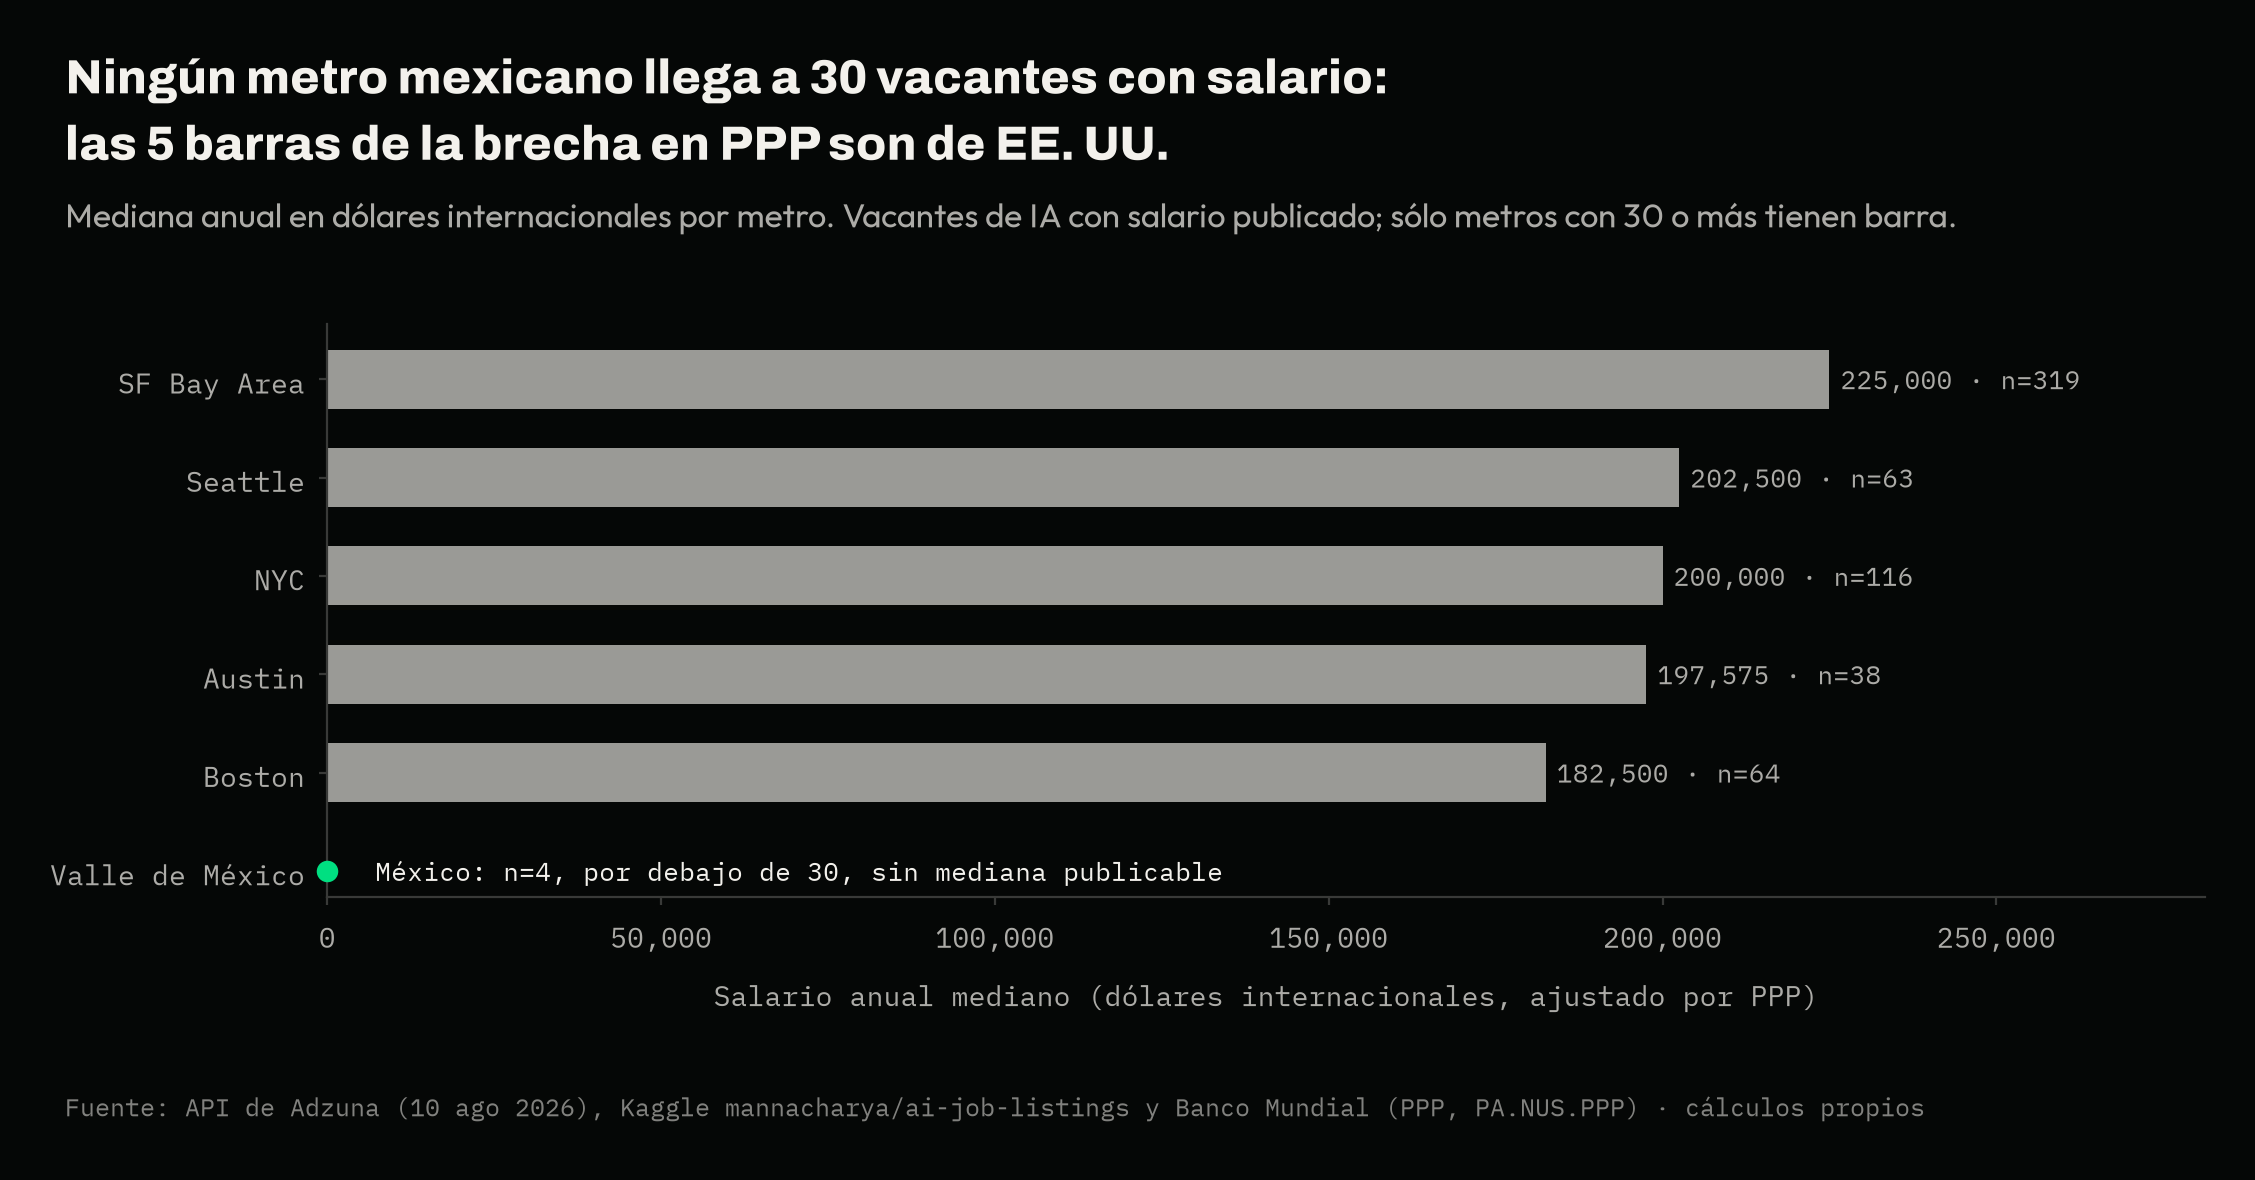

In [11]:
comparativa = resumir_por(ia[ia["metro"].notna()], ["country", "metro"], valor="salary_annual_usd_ppp", min_n=30)
display(comparativa)

comparativa_suf = comparativa[comparativa["suficiente"]].sort_values("mediana")
sin_muestra_mx = comparativa[(comparativa["country"] == "MX") & ~comparativa["suficiente"].astype(bool)]

# Los metros mexicanos que no llegan a 30 se listan abajo, sin barra: la ausencia es el dato.
filas = list(sin_muestra_mx["metro"]) + list(comparativa_suf["metro"])
y = np.arange(len(filas))
k = len(sin_muestra_mx)
fig, ax = plt.subplots(figsize=(11, 5.8))
barras = ax.barh(y[k:], comparativa_suf["mediana"], height=0.6,
                 color=comparativa_suf["country"].map({"MX": PALETA["verde"], "US": PALETA["neutro_claro"]}))
etiquetar(ax, barras, [f"{m:,.0f} · n={int(n)}" for m, n in zip(comparativa_suf["mediana"], comparativa_suf["n"])])
for yi, (_, r) in zip(y[:k], sin_muestra_mx.iterrows()):
    ax.scatter([0], [yi], s=60, color=PALETA["verde"], zorder=3, clip_on=False)
    ax.text(0, yi, f"   México: n={int(r['n'])}, por debajo de 30, sin mediana publicable",
            va="center", fontsize=9.5, color=PALETA["tinta"])
ax.set_yticks(y, filas)
ax.set_xlim(0, comparativa_suf["mediana"].max() * 1.25)
ax.set_xlabel("Salario anual mediano (dólares internacionales, ajustado por PPP)")
miles(ax, "x")
mx_con_muestra = int((comparativa_suf["country"] == "MX").sum())
titulo = (
    f"Ningún metro mexicano llega a 30 vacantes con salario: las {len(comparativa_suf)} barras de la brecha en PPP son de EE. UU."
    if mx_con_muestra == 0
    else f"{mx_con_muestra} metro(s) mexicano(s) ya llegan a 30 vacantes con salario"
)
componer(
    fig,
    titulo,
    "Mediana anual en dólares internacionales por metro. Vacantes de IA con salario publicado; sólo metros con 30 o más tienen barra.",
    "Fuente: API de Adzuna (10 ago 2026), Kaggle mannacharya/ai-job-listings y Banco Mundial (PPP, PA.NUS.PPP) · cálculos propios",
)

**Conclusión — Brecha ajustada por poder adquisitivo.** El único metro mexicano candidato
(Valle de México, n=4) no cruza el umbral, y por eso no aparece ni una sola barra verde en la
gráfica: las cinco barras son metros de EE. UU. Con PPP, la mediana mexicana anecdótica sube de
~\$9,358 a ~\$15,539 (x1.66): el peso rinde más dentro de México de lo que el tipo de cambio
sugiere. La razón US/MX anecdótica baja de ~21x (nominal) a ~13x (PPP) — el ajuste angosta la
brecha aparente, pero **no** la convierte en un número publicable: sigue siendo la mediana de 4
observaciones en una sola ciudad. La sección de Pruebas de hipótesis lo confirma formalmente.

## Pruebas de hipótesis

Dos preguntas formales: ¿CDMX y Querétaro pagan distinto dentro de México?, y ¿EE. UU. y México
pagan distinto en conjunto? Las funciones de `src/analysis/hypothesis.py` exigen n ≥ 30 en ambos
grupos antes de calcular un p-valor; si no se cumple, devuelven `rechaza_h0=None` en vez de un
resultado. Eso es lo que va a pasar en las dos pruebas siguientes, y es el resultado correcto.

In [12]:
cdmx = mx[mx["city"] == "Ciudad de México"]["salary_annual_local"]
qro = mx[mx["city"] == "Querétaro"]["salary_annual_local"]

resultado_ciudades = mann_whitney(cdmx, qro, etiqueta_a="CDMX", etiqueta_b="Querétaro")
display(resultado_ciudades)
print(resultado_ciudades["conclusion"])

{'n_a': 4,
 'n_b': 0,
 'p_valor': None,
 'rechaza_h0': None,
 'conclusion': 'Muestra insuficiente para comparar CDMX (n=4) con Querétaro (n=0). Se requiere n>=30 en ambos.'}

Muestra insuficiente para comparar CDMX (n=4) con Querétaro (n=0). Se requiere n>=30 en ambos.


In [13]:
resultado_paises = welch_log(
    us["salary_annual_usd_ppp"], mx["salary_annual_usd_ppp"],
    etiqueta_a="Estados Unidos", etiqueta_b="México",
)
display(resultado_paises)
print(resultado_paises["conclusion"])

{'n_a': 750,
 'n_b': 4,
 'p_valor': None,
 'rechaza_h0': None,
 'razon_medianas': nan,
 'conclusion': 'Muestra insuficiente (Estados Unidos n=750, México n=4).'}

Muestra insuficiente (Estados Unidos n=750, México n=4).


**Conclusión — Pruebas de hipótesis.** Las dos pruebas se niegan a producir un p-valor, y las
dos tienen razón. Mann-Whitney entre CDMX y Querétaro no corre porque Querétaro tiene n=0
vacantes de IA con salario: no hay nada que comparar. Welch sobre log-salario entre Estados
Unidos y México tampoco corre porque México tiene n=4 frente al umbral de 30 — aun cuando Estados
Unidos aporta 750 observaciones válidas. Forzar `min_n` hacia abajo para obtener un p-valor habría
producido un número con apariencia de rigor estadístico sobre una muestra que no lo sostiene. El
resultado correcto de esta sección es que no hay resultado, y por eso se muestra.

## El arbitraje del remoto

La pregunta: ¿una vacante remota para una empresa de EE. UU., trabajada desde México, paga una
prima sobre una vacante presencial mexicana? Antes de comparar salarios, cuántas vacantes existen
siquiera en esa categoría (`remote_scope = us_desde_mx`), en **todo** el corpus, no sólo en el
subconjunto de IA con salario.

In [14]:
remoto_por_pais = df.groupby(["country", "remote_scope"]).size().unstack(fill_value=0)
display(remoto_por_pais)

remote_scope,global,local,nacional,us_desde_mx
country,,,,
MX,1,309,18,3
US,353,3243,3063,0


In [15]:
resumen_remoto_mx = resumir_por(mx, ["remote_scope"], valor="salary_annual_local", min_n=30)
display(resumen_remoto_mx)

,remote_scope,n,suficiente,mediana,ic_inf,ic_sup,q1,q3
0,local,2,False,NaN,NaN,NaN,NaN,NaN
1,nacional,2,False,NaN,NaN,NaN,NaN,NaN


In [16]:
arbitraje_universo = df[(df["country"] == "MX") & (df["remote_scope"] == "us_desde_mx")]
print(f"Vacantes mexicanas con remote_scope = 'us_desde_mx' en todo el corpus: {len(arbitraje_universo)}")
display(arbitraje_universo[["tier", "salary_observed", "city", "seniority", "title_raw"]])

es_ia = arbitraje_universo["tier"].isin(["nucleo", "anillo"]).sum()
con_salario = int(arbitraje_universo["salary_observed"].sum())
print(f"De ésas, son de IA (núcleo/anillo): {es_ia}")
print(f"De ésas, publican salario: {con_salario}")

hacia_us = mx[mx["remote_scope"] == "us_desde_mx"]["salary_annual_local"]
local = mx[mx["remote_scope"] == "local"]["salary_annual_local"]
resultado_arbitraje = mann_whitney(hacia_us, local, etiqueta_a="Remoto para EE.UU.", etiqueta_b="Presencial en México")
print(f"\n{resultado_arbitraje['conclusion']}")

Vacantes mexicanas con remote_scope = 'us_desde_mx' en todo el corpus: 3


,tier,salary_observed,city,seniority,title_raw
78,fuera,True,Monterrey,sr,"SR Software Engineer (Data focus) - (Remote, L..."
1733,fuera,False,Ciudad de México,unknown,Ejecutivo Comercial B2B
1801,fuera,False,Ciudad de México,unknown,Transcriptor a de Español México Trabajo des...


De ésas, son de IA (núcleo/anillo): 0
De ésas, publican salario: 1

Muestra insuficiente para comparar Remoto para EE.UU. (n=0) con Presencial en México (n=2). Se requiere n>=30 en ambos.


**Conclusión — El arbitraje del remoto.** De 331 vacantes mexicanas capturadas, sólo 3 (0.9 %)
se etiquetan `remote_scope = us_desde_mx`. De esas 3, ninguna es de IA (núcleo/anillo) y sólo 1
publica salario — y es un puesto de software genérico (`tier = fuera`), no de IA. La
intersección que la pregunta necesita (IA + salario + remoto-hacia-EE.UU.) tiene **n=0**, no
n=3: no existe todavía ninguna vacante que permita medir este arbitraje, con o sin regla de
suficiencia. Mann-Whitney lo confirma comparando contra las presenciales mexicanas (n=2) y se
niega a dar un p-valor. La respuesta honesta no es "no hay prima": es "no hay observación".

## Resumen del análisis salarial

**Lo que sí se puede afirmar (n ≥ 30, con intervalo de confianza bootstrap 90 %):**

| Metro (EE. UU.) | n | Mediana anual (USD) | IC 90 % |
|---|---:|---:|---|
| SF Bay Area | 319 | \$225,000 | [\$216,300, \$226,800] |
| Seattle | 63 | \$202,500 | [\$185,000, \$207,500] |
| NYC | 116 | \$200,000 | [\$185,000, \$210,000] |
| Austin | 38 | \$197,575 | [\$168,044, \$209,750] |
| Boston | 64 | \$182,500 | [\$175,000, \$195,000] |

Por seniority en EE. UU.: `staff` (\$238,750, n=81) y `principal` (\$232,625, n=38) pagan más que
`sr` (\$196,520, n=206); `intern` (n=12) no alcanza el umbral.

**Pregunta 1 — ¿Cuánto paga una vacante de IA en CDMX, Querétaro, Monterrey, Guadalajara y en
los principales metros de EE. UU.?** Para EE. UU., la tabla de arriba. Para México, **no se
puede responder con rigor para ninguna de las cuatro ciudades**: Querétaro, Monterrey y
Guadalajara tienen 0 vacantes de IA con salario publicado (aunque sí tienen vacantes de IA sin
salario: 1, 5 y 10 respectivamente). CDMX tiene 4, muy por debajo de n=30. Esos 4 valores —
60,000 · 81,000 · 240,000 · 600,000 MXN/año, un rango de 10x — se citan como anécdota (mediana
≈ \$15,539 USD PPP) y nunca como estimación.

**Pregunta 2 — ¿Cuánto de esa brecha sobrevive al ajuste por poder adquisitivo?** Con las mismas
4 observaciones mexicanas como anécdota: la razón US/MX baja de ~21x en dólares nominales a ~13x
en dólares PPP, porque el peso rinde más dentro de México de lo que el tipo de cambio sugiere.
Formalmente, `welch_log` se niega a dar un p-valor para esta comparación
(`"Muestra insuficiente (Estados Unidos n=750, México n=4)."`), que es el resultado correcto:
ninguna de las dos razones (21x, 13x) es una estimación del mercado mexicano, y ninguna debería
citarse sin ese contexto.

**Pregunta 6 — ¿Existe arbitraje salarial en el remoto hacia EE. UU. desde México?** De 331
vacantes mexicanas, sólo 3 son remoto-hacia-EE. UU., ninguna es de IA, y sólo 1 publica salario
(sin ser de IA). La intersección relevante tiene n=0. La pregunta no tiene evidencia a favor ni
en contra: no hay observación que la responda.

**Cortes que quedaron sin muestra suficiente, en vez de omitirse:**

| Corte | n | Motivo |
|---|---:|---|
| México — Querétaro (IA + salario) | 0 | Sin vacantes de IA con salario publicado |
| México — Monterrey (IA + salario) | 0 | Sin vacantes de IA con salario publicado |
| México — Guadalajara (IA + salario) | 0 | Sin vacantes de IA con salario publicado |
| México — Ciudad de México (IA + salario) | 4 | Por debajo de n=30 |
| México — por seniority | 4 (todas `unknown`) | Sin variación que segmentar |
| México — remote_scope `local` | 2 | Por debajo de n=30 |
| México — remote_scope `nacional` | 2 | Por debajo de n=30 |
| México — remote_scope `us_desde_mx` (IA + salario) | 0 | Ninguna de las 3 vacantes de ese tipo es de IA con salario |
| EE. UU. — Los Angeles (metro) | 20 | Por debajo de n=30 |
| EE. UU. — `intern` (seniority) | 12 | Por debajo de n=30 |
| Mann-Whitney CDMX vs Querétaro | 4 vs 0 | Querétaro sin observaciones |
| Welch (log) Estados Unidos vs México | 750 vs 4 | México por debajo de n=30 |

**Conclusión general.** El mercado estadounidense de IA sí se puede medir: cinco metros con
medianas entre \$182,500 y \$225,000, y una jerarquía de seniority coherente. El mercado
mexicano, en cambio, no se puede medir con esta recolección — no porque no exista (hay 45
vacantes de IA en México), sino porque casi ninguna publica salario (4 de 45, todas en una sola
ciudad). Esa falta de dato no es un vacío que este notebook deba rellenar con imputación o
promedios débiles: es, junto con la brecha misma, uno de los dos hallazgos del proyecto. Cuánto
paga México sigue siendo, con los datos de hoy, una pregunta sin respuesta confiable — y ésa es
la respuesta.